In [1]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

# First Look

In [2]:
df = pd.read_csv('../data/raw/INMATE_ACTIVE_ROOT.txt', sep='\t', encoding='latin-1')
df.head()

,DCNumber,LastName,FirstName,MiddleName,NameSuffix,Race,Sex,BirthDate,PrisonReleaseDate,ReceiptDate,releasedateflag_descr,race_descr,custody_description,FACILITY_description
0,000132,TELFAIR,MICHAEL,NaN,NaN,B,M,12/04/1967,01/27/2033,10/08/2018,valid release date,BLACK,MINIMUM,MADISON C.I.
1,000155,LOCKETT,JERRY,I,NaN,B,M,09/26/1985,05/14/2026,05/23/2024,valid release date,BLACK,MEDIUM,GULF C.I.
2,000175,ELMORE,CHAD,R,NaN,W,M,10/20/1982,07/20/2028,06/11/2025,valid release date,WHITE,CLOSE,JACKSON C.I.
3,000191,CARRILLO,ISAIAS,NaN,JR,W,M,02/21/1998,03/30/2028,09/24/2025,valid release date,WHITE,MEDIUM,APALACHEE EAST UNIT
4,000203,RHINESMITH,AUSTIN,A,NaN,W,M,09/12/2000,09/06/2027,07/24/2025,valid release date,WHITE,MEDIUM,CFRC-EAST


In [3]:
df.shape

(90663, 14)

In [4]:
df.dtypes

DCNumber                 object
LastName                 object
FirstName                object
MiddleName               object
NameSuffix               object
Race                     object
Sex                      object
BirthDate                object
PrisonReleaseDate        object
ReceiptDate              object
releasedateflag_descr    object
race_descr               object
custody_description      object
FACILITY_description     object
dtype: object

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90663 entries, 0 to 90662
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   DCNumber               90663 non-null  object
 1   LastName               90662 non-null  object
 2   FirstName              90663 non-null  object
 3   MiddleName             69042 non-null  object
 4   NameSuffix             7413 non-null   object
 5   Race                   90663 non-null  object
 6   Sex                    90663 non-null  object
 7   BirthDate              90663 non-null  object
 8   PrisonReleaseDate      74745 non-null  object
 9   ReceiptDate            90663 non-null  object
 10  releasedateflag_descr  90663 non-null  object
 11  race_descr             90663 non-null  object
 12  custody_description    88358 non-null  object
 13  FACILITY_description   90663 non-null  object
dtypes: object(14)
memory usage: 9.7+ MB


# Missing Values

The heatmap below visualizes missing data across the dataset. Each column is represented on the x-axis, and each row in the dataset is represented on the y-axis. **Black indicates no missing value, white indicates a missing value.**

From the heatmap we can observe which columns have missing data and how that missingness is distributed across rows — for example, whether missing values tend to cluster together or appear randomly scattered.

In [6]:
# count missing values per column
df.isnull().sum()

DCNumber                     0
LastName                     1
FirstName                    0
MiddleName               21621
NameSuffix               83250
Race                         0
Sex                          0
BirthDate                    0
PrisonReleaseDate        15918
ReceiptDate                  0
releasedateflag_descr        0
race_descr                   0
custody_description       2305
FACILITY_description         0
dtype: int64

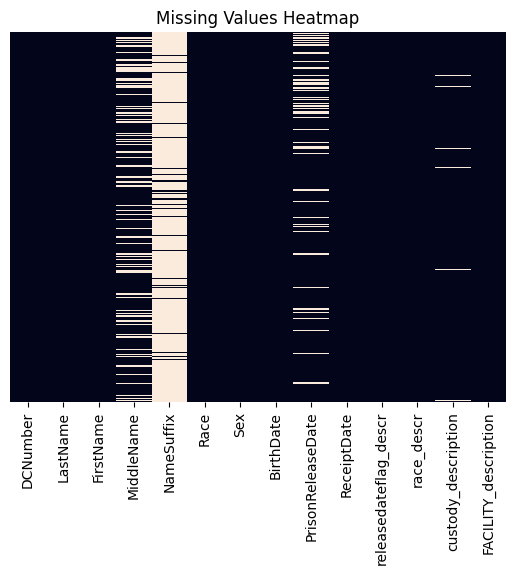

In [7]:
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title('Missing Values Heatmap')
plt.show()

The columns with the most missing values are **MiddleName** and **NameSuffix**. These are not considered critical for analysis — it is common for individuals to not have a middle name on record, and name suffixes (e.g. *Jr.*, *Sr.*, *II*, *III*) are even less common. These columns will be retained but excluded from analysis.

The next most commonly missing field is **PrisonReleaseDate**. This may indicate inmates who are serving life sentences or whose release date has not yet been determined. Further investigation is needed before deciding how to handle this.

A small number of rows are also missing **custody_description**. It is unclear at this stage whether this reflects a data entry issue or a legitimate unknown classification. This will be revisited during the cleaning phase.

# Demographics

In [8]:
# calculate age from birth date and add as a new column
df['BirthDate'] = pd.to_datetime(df['BirthDate'])
df['Age'] = (pd.Timestamp.now() - df['BirthDate']).dt.days // 365 

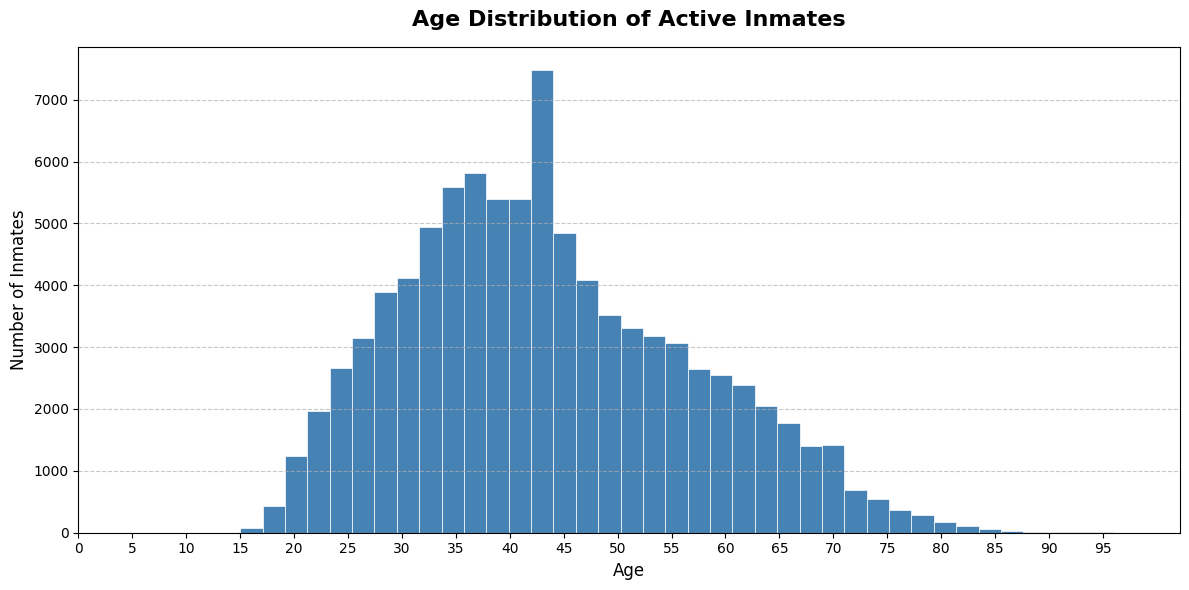

In [9]:
plt.figure(figsize=(12, 6))
plt.hist(df['Age'], bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
plt.title('Age Distribution of Active Inmates', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Number of Inmates', fontsize=12)
plt.xticks(range(0, df['Age'].max()+1, 5), fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [10]:
print("Age Stats:")
print(df['Age'].describe())

Age Stats:
count    90663.000000
mean        43.478641
std         13.234723
min         15.000000
25%         34.000000
50%         42.000000
75%         53.000000
max         98.000000
Name: Age, dtype: float64


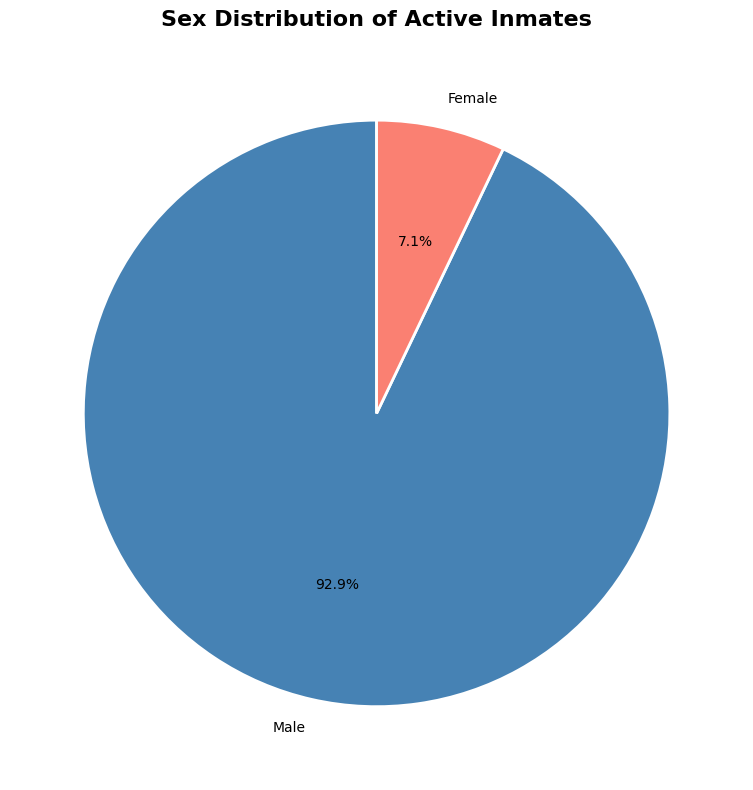

In [11]:
plt.figure(figsize=(8, 8))
sex_counts = df['Sex'].value_counts()
plt.pie(sex_counts, 
        labels=sex_counts.index.map({'M': 'Male', 'F': 'Female'}),
        autopct='%1.1f%%',
        colors=['steelblue', 'salmon'],
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
plt.title('Sex Distribution of Active Inmates', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

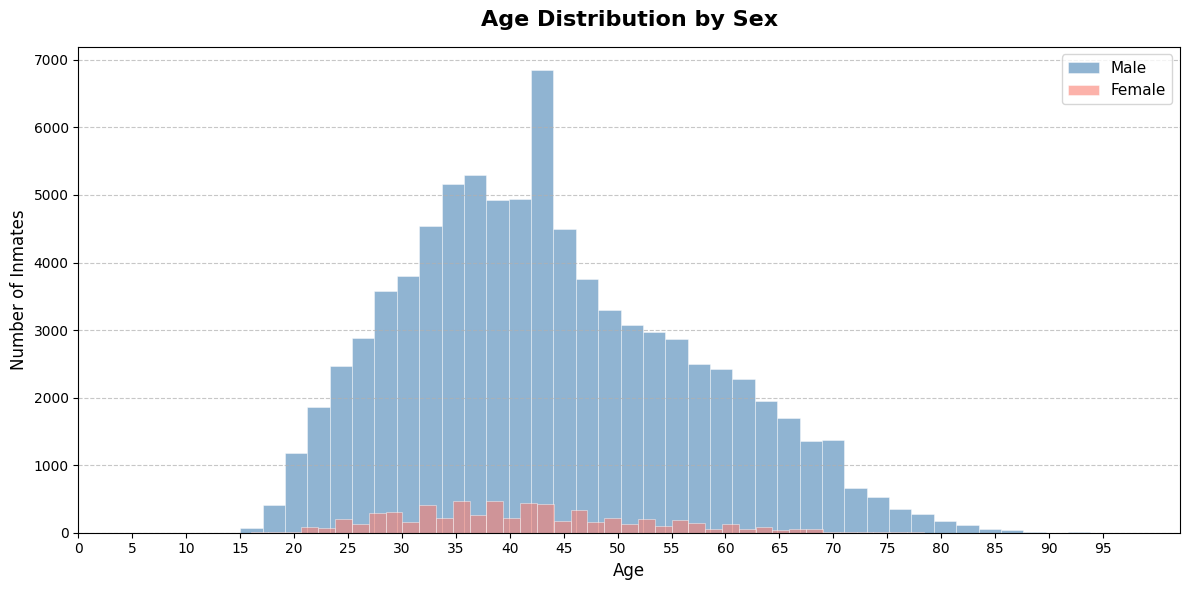

In [12]:
plt.figure(figsize=(12, 6))

male = df[df['Sex'] == 'M']['Age']
female = df[df['Sex'] == 'F']['Age']

plt.hist(male, bins=40, color='steelblue', edgecolor='white', linewidth=0.5, alpha=0.6, label='Male')
plt.hist(female, bins=50, color='salmon', edgecolor='white', linewidth=0.5, alpha=0.6, label='Female')

plt.title('Age Distribution by Sex', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Number of Inmates', fontsize=12)
plt.xticks(range(0, df['Age'].max()+1, 5), fontsize=10)
plt.yticks(fontsize=10)
plt.legend(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [13]:
print("Male vs Female Age Stats:")
print(df.groupby('Sex')['Age'].describe())

Male vs Female Age Stats:
       count       mean        std   min   25%   50%   75%   max
Sex                                                             
F     6444.0  41.443513  11.467006  16.0  33.0  40.0  48.0  94.0
M    84219.0  43.634358  13.347637  15.0  34.0  42.0  53.0  98.0


In [14]:
df['race_descr'].unique()

array(['BLACK', 'WHITE', 'HISPANIC', 'ALL OTHERS/UNKNOWN',
       'AMERICAN INDIAN OR PACIFIC ISL', 'ASIAN OR PACIFIC ISLANDER'],
      dtype=object)

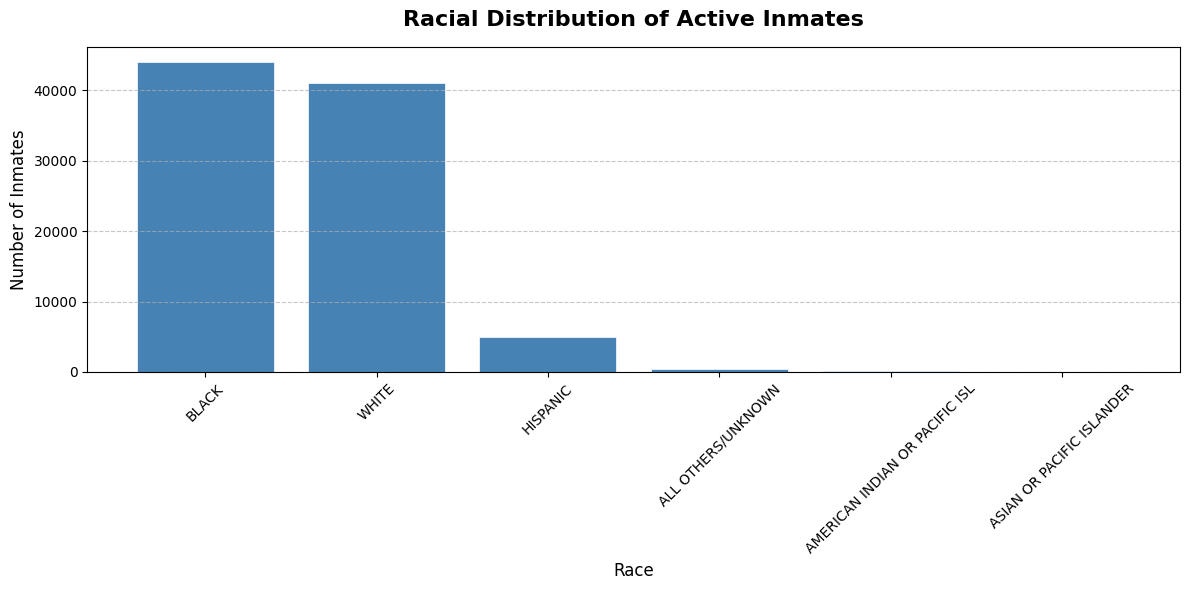

                                Count Percentage
race_descr                                      
BLACK                           44003     48.53%
WHITE                           41067      45.3%
HISPANIC                         5027      5.54%
ALL OTHERS/UNKNOWN                427      0.47%
AMERICAN INDIAN OR PACIFIC ISL    109      0.12%
ASIAN OR PACIFIC ISLANDER          30      0.03%


In [15]:
# Bar chart
race_counts = df['race_descr'].value_counts()

plt.figure(figsize=(12, 6))
plt.bar(race_counts.index, race_counts.values, color='steelblue', edgecolor='white', linewidth=0.5)
plt.title('Racial Distribution of Active Inmates', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Race', fontsize=12)
plt.ylabel('Number of Inmates', fontsize=12)
plt.xticks(fontsize=10, rotation=45)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Percentage table
race_pct = pd.DataFrame({
    'Count': race_counts,
    'Percentage': (race_counts / race_counts.sum() * 100).round(2).astype(str) + '%'
})
print(race_pct)